# 3.0 Business Analysis Overview

- This notebook transitions from KPI measurement into business interpretation.
- The objective is to identify the key drivers behind revenue performance and operational behavior.
- Analysis will focus on explaining patterns found in Workbook 2, including:
  - peak revenue windows
  - day-of-week performance
  - AOV behavior
  - discount impact
  - server-level performance
- SQL will continue to be used for structured analysis and business queries.
- Python will be used for validation, visualization, and supporting interpretation.
- The goal is to convert performance metrics into actionable recommendations tied to:
  - revenue growth
  - operational efficiency
  - staffing decisions
  - promotion strategy
- This notebook answers the question: “What should the business do with these insights?”

In [18]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

# Reconnect to DuckDB
con = duckdb.connect(database=':memory:')

# Reload cleaned dataset
con.execute("""
CREATE OR REPLACE TABLE orders_clean AS
SELECT * FROM read_csv_auto('data/cleaned/orders_clean.csv');
""")

# Quick validation
con.execute("SELECT COUNT(*) FROM orders_clean").fetchdf()

,count_star()
0,22156


## 3.1 Peak Revenue Drivers

- Identify the primary drivers of revenue based on time-based patterns.
- Analyze peak hours and peak days identified in Workbook 2.
- Quantify how much revenue is concentrated within peak time windows.
- Determine whether the business relies heavily on specific time periods.
- This helps assess operational risk and opportunity for revenue expansion.

In [19]:
# Revenue concentration by top hours

peak_hours_df = con.execute("""
SELECT
    EXTRACT(HOUR FROM order_datetime) AS order_hour,
    SUM(order_total) AS total_revenue
FROM orders_clean
GROUP BY EXTRACT(HOUR FROM order_datetime)
ORDER BY total_revenue DESC
""").fetchdf()

peak_hours_df

,order_hour,total_revenue
0,11,92533.05
1,17,90153.19
2,12,86567.47
3,18,81880.89
4,16,66872.10
5,13,42734.53
6,19,42504.80
7,15,40481.66
8,14,32313.08
9,10,1024.07


## 3.2 Revenue Concentration Analysis

- Calculate cumulative revenue contribution from top-performing hours.
- Determine what percentage of total revenue comes from a small number of hours.
- This reveals whether the business is concentrated or evenly distributed.

In [20]:
# Calculate cumulative share

peak_hours_df = peak_hours_df.sort_values('total_revenue', ascending=False)
peak_hours_df['cumulative_revenue'] = peak_hours_df['total_revenue'].cumsum()

total_rev = peak_hours_df['total_revenue'].sum()
peak_hours_df['cumulative_pct'] = (peak_hours_df['cumulative_revenue'] / total_rev) * 100

peak_hours_df

,order_hour,total_revenue,cumulative_revenue,cumulative_pct
0,11,92533.05,92533.05,16.028822
1,17,90153.19,182686.24,31.645397
2,12,86567.47,269253.71,46.640845
3,18,81880.89,351134.60,60.824471
4,16,66872.10,418006.70,72.408235
5,13,42734.53,460741.23,79.810824
6,19,42504.80,503246.03,87.173619
7,15,40481.66,543727.69,94.185960
8,14,32313.08,576040.77,99.783318
9,10,1024.07,577064.84,99.960710


## 3.3 Peak Dependency Insight

- Evaluate how dependent the business is on peak hours.
- Identify whether a small number of hours drive a disproportionate share of revenue.
- High concentration indicates potential operational bottlenecks and risk.
- Low concentration suggests more stable, evenly distributed demand.

## 3.4 Underutilized Time Analysis

- Identify hours with low revenue and low order volume to detect underutilized operating periods.
- Quantify the share of revenue generated during off-peak hours.
- Compare off-peak vs peak performance to understand imbalance in demand.
- Highlight potential opportunities to increase utilization through promotions or operational adjustments.
- This analysis shifts focus from “where revenue is generated” to “where revenue is missing.”

In [21]:
# Identify low-performing hours (bottom revenue hours)

low_hours_df = con.execute("""
SELECT
    EXTRACT(HOUR FROM order_datetime) AS order_hour,
    COUNT(*) AS total_orders,
    SUM(order_total) AS total_revenue
FROM orders_clean
GROUP BY EXTRACT(HOUR FROM order_datetime)
ORDER BY total_revenue ASC
""").fetchdf()

low_hours_df

,order_hour,total_orders,total_revenue
0,9,1,5.25
1,20,13,221.57
2,10,64,1024.07
3,14,1381,32313.08
4,15,1617,40481.66
5,19,1560,42504.80
6,13,1841,42734.53
7,16,2517,66872.10
8,18,2838,81880.89
9,12,3259,86567.47


## 3.5 Off-Peak Revenue Contribution

- Calculate how much total revenue comes from the lowest-performing hours.
- Determine whether off-peak hours contribute meaningfully to overall revenue.
- This helps quantify the opportunity size for demand expansion strategies.

In [22]:
# Calculate contribution of bottom hours

low_hours_df['cumulative_revenue'] = low_hours_df['total_revenue'].cumsum()

total_rev = low_hours_df['total_revenue'].sum()
low_hours_df['cumulative_pct'] = (low_hours_df['cumulative_revenue'] / total_rev) * 100

low_hours_df

,order_hour,total_orders,total_revenue,cumulative_revenue,cumulative_pct
0,9,1,5.25,5.25,0.000909
1,20,13,221.57,226.82,0.039290
2,10,64,1024.07,1250.89,0.216682
3,14,1381,32313.08,33563.97,5.814040
4,15,1617,40481.66,74045.63,12.826381
5,19,1560,42504.80,116550.43,20.189176
6,13,1841,42734.53,159284.96,27.591765
7,16,2517,66872.10,226157.06,39.175529
8,18,2838,81880.89,308037.95,53.359155
9,12,3259,86567.47,394605.42,68.354603


## 3.6 Underutilization Insight

- Evaluate how much of the day generates minimal revenue.
- Identify extended periods of low activity.
- Determine whether the business is overstaffed or under-leveraged during these hours.
- This section supports decisions related to:
  - adjusted operating hours
  - targeted promotions
  - labor optimization

## 3.7 AOV Drivers Analysis

- Investigate what factors influence Average Order Value (AOV).
- Analyze how AOV varies across:
  - guest count
  - time of day (hour)
  - day of week
- Identify patterns that explain why some orders are higher value than others.
- Determine whether larger parties or specific time windows drive higher revenue per transaction.
- This analysis helps uncover practical levers for increasing revenue without increasing order volume.

In [23]:
# AOV by guest count
aov_guest_df = con.execute("""
SELECT
    guest_count,
    COUNT(*) AS total_orders,
    AVG(order_total) AS avg_order_value
FROM orders_clean
GROUP BY guest_count
HAVING COUNT(*) >= 20
ORDER BY guest_count
""").fetchdf()

aov_guest_df

,guest_count,total_orders,avg_order_value
0,1,19734,24.828612
1,2,1513,28.710681
2,3,422,38.290782
3,4,269,47.466766
4,5,103,60.606505
5,6,55,75.010182
6,7,21,83.020000


## 3.8 AOV by Guest Count Visualization

- Visualize how AOV changes as guest count increases.
- Identify whether larger parties significantly increase ticket size.
- This helps determine whether group size is a primary revenue driver.

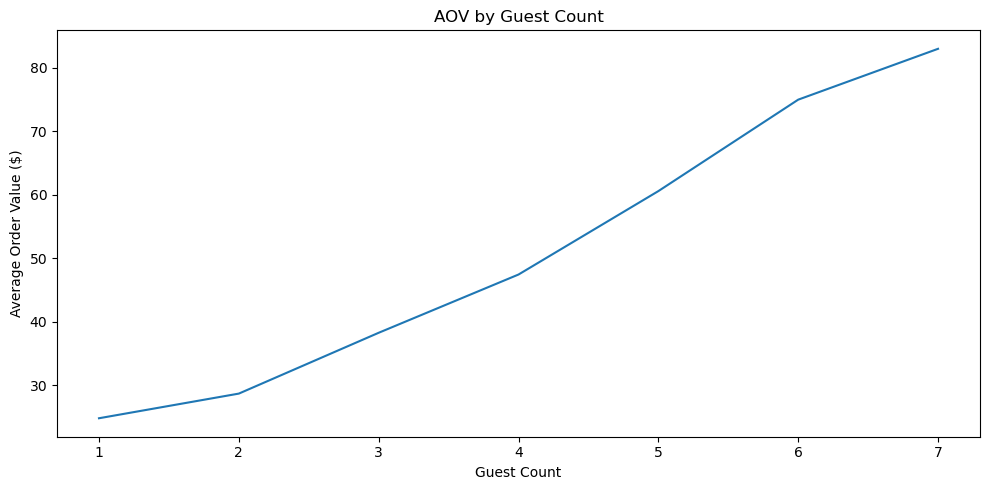

In [24]:
plt.figure(figsize=(10,5))
plt.plot(aov_guest_df['guest_count'], aov_guest_df['avg_order_value'])
plt.title('AOV by Guest Count')
plt.xlabel('Guest Count')
plt.ylabel('Average Order Value ($)')
plt.tight_layout()
plt.show()

## 3.9 AOV by Hour of Day

- Analyze how AOV varies across different hours.
- Determine whether higher-value transactions occur during peak hours or off-peak periods.
- Identify potential time-based upselling opportunities.

In [25]:
aov_hour_df = con.execute("""
SELECT
    EXTRACT(HOUR FROM order_datetime) AS order_hour,
    AVG(order_total) AS avg_order_value
FROM orders_clean
GROUP BY EXTRACT(HOUR FROM order_datetime)
HAVING EXTRACT(HOUR FROM order_datetime) BETWEEN 10 AND 20
ORDER BY order_hour
""").fetchdf()

aov_hour_df

,order_hour,avg_order_value
0,10,16.001094
1,11,24.090875
2,12,26.562587
3,13,23.212672
4,14,23.398320
5,15,25.035040
6,16,26.568176
7,17,27.963148
8,18,28.851617
9,19,27.246667


## 3.10 AOV by Hour Visualization

- Visualize AOV across hours of the day.
- Compare AOV trends with revenue and order volume patterns.
- This helps determine whether high-revenue hours are driven by volume or higher ticket size.

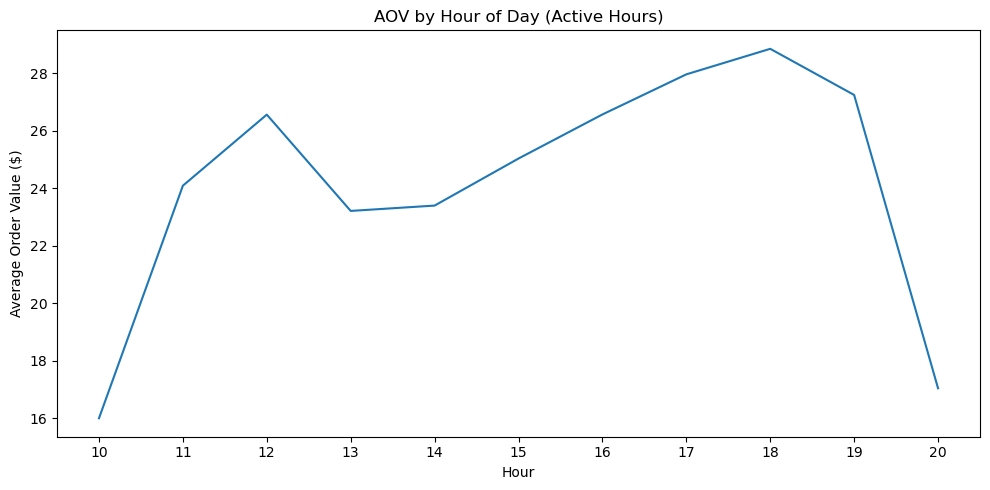

In [26]:
plt.figure(figsize=(10,5))
plt.plot(aov_hour_df['order_hour'], aov_hour_df['avg_order_value'])

plt.title('AOV by Hour of Day (Active Hours)')
plt.xlabel('Hour')
plt.ylabel('Average Order Value ($)')
plt.xticks(range(10,21))

plt.tight_layout()
plt.show()

## 3.11 AOV Driver Insight

- Evaluate which factors most strongly influence AOV:
  - guest count
  - time of day
- Determine whether AOV growth is driven more by party size or timing.
- Identify practical levers to increase revenue:
  - upselling strategies
  - group targeting
  - time-based promotions

## 3.12 Operational Constraints Analysis

- Identify where operational limitations may be restricting revenue growth.
- Use peak hour concentration and demand patterns to detect capacity pressure.
- Evaluate whether high-demand periods are likely constrained by:
  - kitchen throughput
  - staffing levels
  - service speed
- Determine whether revenue growth is limited by demand or operational capacity.
- This analysis bridges data insights with real-world business operations.

In [27]:
peak_volume_df = con.execute("""
SELECT
    EXTRACT(HOUR FROM order_datetime) AS order_hour,
    COUNT(*) AS total_orders,
    SUM(order_total) AS total_revenue
FROM orders_clean
GROUP BY EXTRACT(HOUR FROM order_datetime)
ORDER BY total_orders DESC
""").fetchdf()

peak_volume_df

,order_hour,total_orders,total_revenue
0,11,3841,92533.05
1,12,3259,86567.47
2,17,3224,90153.19
3,18,2838,81880.89
4,16,2517,66872.10
5,13,1841,42734.53
6,15,1617,40481.66
7,19,1560,42504.80
8,14,1381,32313.08
9,10,64,1024.07


## 3.13 Revenue Driver Summary

- Synthesize findings from KPI analysis and business interpretation to identify the primary drivers of revenue.
- Consolidate insights across:
  - time-based demand (hour, day)
  - AOV behavior
  - discount usage
  - server performance
- Clearly distinguish between:
  - demand-driven factors (when customers buy)
  - efficiency-driven factors (how much they spend)
- This section establishes a structured understanding of what drives revenue in the business.

### Key Findings

- **Time-Based Demand Dominates**
  - A significant portion of revenue is concentrated in a small number of peak hours (lunch and dinner windows).
  - Approximately ~60% of revenue is generated within a limited set of high-demand hours.
  - Demand is not evenly distributed across the day.

- **Underutilized Capacity Exists**
  - Several operating hours generate minimal revenue, indicating unused capacity.
  - Off-peak periods represent potential opportunities for demand generation or cost optimization.

- **AOV is Driven by Guest Count**
  - Average order value increases consistently with guest count.
  - Larger parties contribute disproportionately higher revenue per transaction.
  - Group size is a key lever for revenue growth.

- **Discount Strategy is Minimal**
  - Discount usage is extremely low and does not meaningfully contribute to revenue.
  - Discounted orders have slightly lower AOV, suggesting no strong incentive effect.

- **Operational Constraints Likely at Peak**
  - High order concentration during peak hours suggests potential bottlenecks.
  - Revenue may be limited by service capacity rather than demand.

- **Server Performance Varies**
  - Differences in revenue contribution and AOV across servers indicate variability in execution and upselling.

### Overall Conclusion

- Revenue is primarily driven by **time-based demand concentration** and **order value scaling with group size**.
- The business currently operates with:
  - strong peak demand
  - limited use of promotions
  - potential operational constraints during high-volume periods

- Growth opportunities exist in:
  - expanding off-peak demand
  - improving peak-hour throughput
  - leveraging group-based purchasing behavior

## 3.14 SQL Time-Based Analysis

- Analyze demand patterns by hour using SQL.
- Derive order_hour directly from order_datetime.
- Identifies peak hours, revenue concentration, and AOV trends.

In [34]:
import pandas as pd
import duckdb

# Load cleaned dataset
orders_clean = pd.read_csv("../data/cleaned/orders_clean.csv")

# Restore datetime type after CSV reload
orders_clean["order_datetime"] = pd.to_datetime(orders_clean["order_datetime"])

# Create DuckDB connection
con = duckdb.connect()
con.register("orders_clean", orders_clean)

# SQL time-based analysis
con.execute("""
SELECT
    EXTRACT(HOUR FROM order_datetime) AS order_hour,
    COUNT(*) AS total_orders,
    ROUND(AVG(order_total), 2) AS avg_order_value,
    SUM(order_total) AS total_revenue
FROM orders_clean
GROUP BY order_hour
ORDER BY order_hour
""").fetchdf()

,order_hour,total_orders,avg_order_value,total_revenue
0,9,1,5.25,5.25
1,10,64,16.00,1024.07
2,11,3841,24.09,92533.05
3,12,3259,26.56,86567.47
4,13,1841,23.21,42734.53
5,14,1381,23.40,32313.08
6,15,1617,25.04,40481.66
7,16,2517,26.57,66872.10
8,17,3224,27.96,90153.19
9,18,2838,28.85,81880.89
